# 11 — Full-dataset inference milestone

This notebook creates a reproducible LiDAR-only baseline before camera–LiDAR fusion.

It produces two different measurements:

1. **KITTI testing inference:** runs every unlabeled test frame and reports throughput, confidence, detection counts, and distance distributions. It saves every predicted box.
2. **Held-out validation evaluation:** runs the checkpoint's labeled validation indices and reports center-matched precision, recall, F1, TP, FP, FN, and distance-binned metrics.

> KITTI's local `testing` split contains no labels. Test-set statistics are useful operational measurements, but they are not accuracy. Accuracy is measured on the held-out labeled validation split.


In [ ]:
import csv
import json
import math
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").is_dir() else CURRENT_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_dataset import KittiDataset
from src.geometry.boxes import get_lidar_boxes
from src.inference.decode import decode_predictions
from src.models.bev_detector import BEVDetector
from src.preprocessing.bev import bev_projection

CHECKPOINT_PATH = PROJECT_ROOT / "outputs" / "bev_detector_multiscale_full.pth"
DATA_ROOT = PROJECT_ROOT / "data" / "KITTI"
MILESTONE_DIR = PROJECT_ROOT / "outputs" / "milestone_lidar_only"

SCORE_THRESHOLD = 0.30
TOP_K = 50
MIN_CENTER_DISTANCE = 1.5
MATCH_DISTANCE_METERS = 2.0
PROGRESS_EVERY = 100
RUN_VALIDATION_EVALUATION = True

MILESTONE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

model = BEVDetector().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Project root:", PROJECT_ROOT)
print("Checkpoint:", CHECKPOINT_PATH.name)
print("Architecture:", checkpoint.get("config", {}).get("architecture", "unknown"))
print("Device:", device)


Project root: /home/rahul/projects/kitti-lidar-detector
Checkpoint: bev_detector_multiscale_full.pth
Architecture: multiscale_encoder_decoder_v1
Device: cuda


In [2]:
def synchronize_device():
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def run_frame(sample):
    """Create BEV, run the detector, decode boxes, and return timings."""
    preprocess_start = time.perf_counter()
    bev = bev_projection(sample["points"])
    bev_tensor = torch.from_numpy(bev).float().unsqueeze(0).to(
        device,
        non_blocking=device.type == "cuda",
    )
    synchronize_device()
    preprocess_ms = (time.perf_counter() - preprocess_start) * 1000.0

    inference_start = time.perf_counter()
    with torch.inference_mode():
        outputs = model(bev_tensor)
        detections = decode_predictions(
            outputs,
            score_threshold=SCORE_THRESHOLD,
            top_k=TOP_K,
            min_center_distance=MIN_CENTER_DISTANCE,
        )
    synchronize_device()
    inference_ms = (time.perf_counter() - inference_start) * 1000.0

    return detections, preprocess_ms, inference_ms


def match_by_center_distance(detections, ground_truth, max_distance):
    """Greedy one-to-one matching, processing highest-confidence boxes first."""
    matched_pairs = []
    unmatched_gt = set(range(len(ground_truth)))

    detection_order = sorted(
        range(len(detections)),
        key=lambda index: detections[index]["score"],
        reverse=True,
    )

    for detection_index in detection_order:
        detection = detections[detection_index]
        candidates = []

        for gt_index in unmatched_gt:
            box = ground_truth[gt_index]
            distance = math.hypot(
                detection["center_x"] - box["center_x"],
                detection["center_y"] - box["center_y"],
            )
            candidates.append((distance, gt_index))

        if not candidates:
            continue

        distance, gt_index = min(candidates)
        if distance <= max_distance:
            matched_pairs.append((detection_index, gt_index, distance))
            unmatched_gt.remove(gt_index)

    matched_detection_indices = {
        detection_index
        for detection_index, _, _ in matched_pairs
    }
    false_positive_indices = (
        set(range(len(detections))) - matched_detection_indices
    )

    return matched_pairs, false_positive_indices, unmatched_gt


def distance_bin(center_x):
    if center_x < 30.0:
        return "near_0_30m"
    if center_x < 50.0:
        return "medium_30_50m"
    return "far_50_70m"


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def percentile(values, q):
    return float(np.percentile(values, q)) if values else 0.0


def write_json(path, value):
    with path.open("w", encoding="utf-8") as file:
        json.dump(value, file, indent=2)


def print_summary(summary):
    print(json.dumps(summary, indent=2))


In [3]:
# Run inference over every KITTI testing frame.
test_dataset = KittiDataset(DATA_ROOT, split="testing")
test_frame_rows = []
test_prediction_rows = []
all_test_scores = []
all_test_distances = []

test_started = time.perf_counter()

for dataset_index in range(len(test_dataset)):
    sample = test_dataset[dataset_index]
    detections, preprocess_ms, inference_ms = run_frame(sample)

    scores = [detection["score"] for detection in detections]
    distances = [
        math.hypot(detection["center_x"], detection["center_y"])
        for detection in detections
    ]
    all_test_scores.extend(scores)
    all_test_distances.extend(distances)

    test_frame_rows.append({
        "sample_id": sample["id"],
        "num_points": len(sample["points"]),
        "num_detections": len(detections),
        "max_score": max(scores, default=0.0),
        "mean_score": float(np.mean(scores)) if scores else 0.0,
        "preprocess_ms": preprocess_ms,
        "inference_decode_ms": inference_ms,
    })
    test_prediction_rows.append({
        "sample_id": sample["id"],
        "detections": detections,
    })

    completed = dataset_index + 1
    if completed % PROGRESS_EVERY == 0 or completed == len(test_dataset):
        elapsed = time.perf_counter() - test_started
        print(
            f"Testing: {completed}/{len(test_dataset)} frames "
            f"({completed / elapsed:.2f} frames/s)"
        )

test_elapsed = time.perf_counter() - test_started

with (MILESTONE_DIR / "test_predictions.jsonl").open(
    "w",
    encoding="utf-8",
) as file:
    for row in test_prediction_rows:
        file.write(json.dumps(row) + "\n")

with (MILESTONE_DIR / "test_frame_metrics.csv").open(
    "w",
    newline="",
    encoding="utf-8",
) as file:
    writer = csv.DictWriter(file, fieldnames=test_frame_rows[0].keys())
    writer.writeheader()
    writer.writerows(test_frame_rows)

total_test_detections = sum(
    row["num_detections"] for row in test_frame_rows
)
frames_with_detections = sum(
    row["num_detections"] > 0 for row in test_frame_rows
)
inference_times = [
    row["inference_decode_ms"] for row in test_frame_rows
]
preprocess_times = [
    row["preprocess_ms"] for row in test_frame_rows
]

test_summary = {
    "dataset_split": "testing",
    "labels_available": False,
    "checkpoint": CHECKPOINT_PATH.name,
    "architecture": checkpoint.get("config", {}).get(
        "architecture",
        "unknown",
    ),
    "device": str(device),
    "score_threshold": SCORE_THRESHOLD,
    "top_k": TOP_K,
    "min_center_distance": MIN_CENTER_DISTANCE,
    "frames": len(test_dataset),
    "total_detections": total_test_detections,
    "frames_with_detections": frames_with_detections,
    "frames_without_detections": (
        len(test_dataset) - frames_with_detections
    ),
    "detections_per_frame_mean": safe_divide(
        total_test_detections,
        len(test_dataset),
    ),
    "confidence_mean": (
        float(np.mean(all_test_scores)) if all_test_scores else 0.0
    ),
    "confidence_median": percentile(all_test_scores, 50),
    "confidence_p90": percentile(all_test_scores, 90),
    "preprocess_ms_mean": float(np.mean(preprocess_times)),
    "inference_decode_ms_mean": float(np.mean(inference_times)),
    "inference_decode_ms_p95": percentile(inference_times, 95),
    "end_to_end_frames_per_second": safe_divide(
        len(test_dataset),
        test_elapsed,
    ),
    "elapsed_seconds": test_elapsed,
}

write_json(MILESTONE_DIR / "test_summary.json", test_summary)
print_summary(test_summary)


Testing: 100/7518 frames (23.39 frames/s)
Testing: 200/7518 frames (24.49 frames/s)
Testing: 300/7518 frames (24.62 frames/s)
Testing: 400/7518 frames (24.67 frames/s)
Testing: 500/7518 frames (24.85 frames/s)
Testing: 600/7518 frames (25.13 frames/s)
Testing: 700/7518 frames (25.33 frames/s)
Testing: 800/7518 frames (25.55 frames/s)
Testing: 900/7518 frames (25.69 frames/s)
Testing: 1000/7518 frames (25.80 frames/s)
Testing: 1100/7518 frames (25.89 frames/s)
Testing: 1200/7518 frames (25.87 frames/s)
Testing: 1300/7518 frames (25.88 frames/s)
Testing: 1400/7518 frames (25.86 frames/s)
Testing: 1500/7518 frames (25.88 frames/s)
Testing: 1600/7518 frames (25.97 frames/s)
Testing: 1700/7518 frames (26.05 frames/s)
Testing: 1800/7518 frames (26.11 frames/s)
Testing: 1900/7518 frames (26.16 frames/s)
Testing: 2000/7518 frames (26.20 frames/s)
Testing: 2100/7518 frames (26.23 frames/s)
Testing: 2200/7518 frames (26.25 frames/s)
Testing: 2300/7518 frames (26.26 frames/s)
Testing: 2400/7518 f

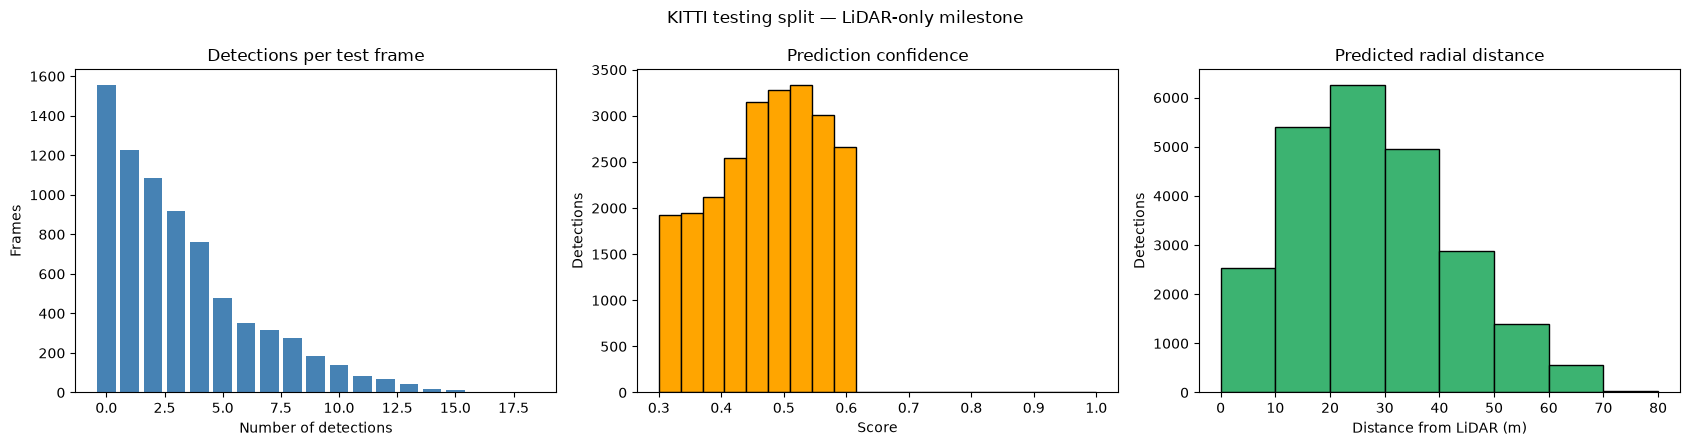

Saved test artifacts to: /home/rahul/projects/kitti-lidar-detector/outputs/milestone_lidar_only
 - test_predictions.jsonl
 - test_frame_metrics.csv
 - test_summary.json


In [4]:
# Operational test-set plots. These are not accuracy plots.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

detection_counts = [
    row["num_detections"] for row in test_frame_rows
]
count_frequencies = Counter(detection_counts)
axes[0].bar(
    sorted(count_frequencies),
    [count_frequencies[count] for count in sorted(count_frequencies)],
    color="steelblue",
)
axes[0].set_title("Detections per test frame")
axes[0].set_xlabel("Number of detections")
axes[0].set_ylabel("Frames")

axes[1].hist(
    all_test_scores,
    bins=20,
    range=(SCORE_THRESHOLD, 1.0),
    color="orange",
    edgecolor="black",
)
axes[1].set_title("Prediction confidence")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Detections")

axes[2].hist(
    all_test_distances,
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
    color="mediumseagreen",
    edgecolor="black",
)
axes[2].set_title("Predicted radial distance")
axes[2].set_xlabel("Distance from LiDAR (m)")
axes[2].set_ylabel("Detections")

fig.suptitle("KITTI testing split — LiDAR-only milestone")
fig.tight_layout()
plt.show()

print("Saved test artifacts to:", MILESTONE_DIR)
print(" - test_predictions.jsonl")
print(" - test_frame_metrics.csv")
print(" - test_summary.json")


In [5]:
# Evaluate accuracy on the checkpoint's held-out labeled validation set.
if RUN_VALIDATION_EVALUATION:
    training_dataset = KittiDataset(DATA_ROOT, split="training")
    validation_indices = checkpoint["split"]["validation_indices"]

    totals = {"tp": 0, "fp": 0, "fn": 0}
    distance_totals = {
        name: {"tp": 0, "fp": 0, "fn": 0}
        for name in ("near_0_30m", "medium_30_50m", "far_50_70m")
    }
    validation_rows = []
    center_errors = []
    validation_started = time.perf_counter()

    for position, dataset_index in enumerate(validation_indices):
        sample = training_dataset[dataset_index]
        detections, preprocess_ms, inference_ms = run_frame(sample)
        ground_truth = get_lidar_boxes(
            sample["labels"],
            sample["calib"],
        )

        matched, false_positive_indices, missed_gt_indices = (
            match_by_center_distance(
                detections,
                ground_truth,
                MATCH_DISTANCE_METERS,
            )
        )

        tp = len(matched)
        fp = len(false_positive_indices)
        fn = len(missed_gt_indices)
        totals["tp"] += tp
        totals["fp"] += fp
        totals["fn"] += fn
        center_errors.extend(
            distance for _, _, distance in matched
        )

        for _, gt_index, _ in matched:
            distance_totals[
                distance_bin(ground_truth[gt_index]["center_x"])
            ]["tp"] += 1

        for detection_index in false_positive_indices:
            distance_totals[
                distance_bin(detections[detection_index]["center_x"])
            ]["fp"] += 1

        for gt_index in missed_gt_indices:
            distance_totals[
                distance_bin(ground_truth[gt_index]["center_x"])
            ]["fn"] += 1

        validation_rows.append({
            "sample_id": sample["id"],
            "dataset_index": dataset_index,
            "ground_truth": len(ground_truth),
            "detections": len(detections),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": safe_divide(tp, tp + fp),
            "recall": safe_divide(tp, tp + fn),
            "preprocess_ms": preprocess_ms,
            "inference_decode_ms": inference_ms,
        })

        completed = position + 1
        if (
            completed % PROGRESS_EVERY == 0
            or completed == len(validation_indices)
        ):
            elapsed = time.perf_counter() - validation_started
            print(
                f"Validation: {completed}/{len(validation_indices)} frames "
                f"({completed / elapsed:.2f} frames/s)"
            )

    precision = safe_divide(totals["tp"], totals["tp"] + totals["fp"])
    recall = safe_divide(totals["tp"], totals["tp"] + totals["fn"])
    f1 = safe_divide(2 * precision * recall, precision + recall)

    per_distance = {}
    for name, values in distance_totals.items():
        bin_precision = safe_divide(
            values["tp"],
            values["tp"] + values["fp"],
        )
        bin_recall = safe_divide(
            values["tp"],
            values["tp"] + values["fn"],
        )
        per_distance[name] = {
            **values,
            "precision": bin_precision,
            "recall": bin_recall,
            "f1": safe_divide(
                2 * bin_precision * bin_recall,
                bin_precision + bin_recall,
            ),
        }

    validation_summary = {
        "dataset_split": "training/held-out-validation",
        "checkpoint": CHECKPOINT_PATH.name,
        "frames": len(validation_indices),
        "score_threshold": SCORE_THRESHOLD,
        "match_distance_meters": MATCH_DISTANCE_METERS,
        **totals,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "matched_center_error_mean_m": (
            float(np.mean(center_errors)) if center_errors else 0.0
        ),
        "matched_center_error_p95_m": percentile(center_errors, 95),
        "per_distance": per_distance,
        "elapsed_seconds": time.perf_counter() - validation_started,
    }

    with (MILESTONE_DIR / "validation_frame_metrics.csv").open(
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=validation_rows[0].keys(),
        )
        writer.writeheader()
        writer.writerows(validation_rows)

    write_json(
        MILESTONE_DIR / "validation_summary.json",
        validation_summary,
    )
    print_summary(validation_summary)


Validation: 100/1496 frames (25.70 frames/s)
Validation: 200/1496 frames (25.91 frames/s)
Validation: 300/1496 frames (26.15 frames/s)
Validation: 400/1496 frames (26.35 frames/s)
Validation: 500/1496 frames (26.41 frames/s)
Validation: 600/1496 frames (26.44 frames/s)
Validation: 700/1496 frames (26.54 frames/s)
Validation: 800/1496 frames (26.55 frames/s)
Validation: 900/1496 frames (26.52 frames/s)
Validation: 1000/1496 frames (26.46 frames/s)
Validation: 1100/1496 frames (26.48 frames/s)
Validation: 1200/1496 frames (26.50 frames/s)
Validation: 1300/1496 frames (26.53 frames/s)
Validation: 1400/1496 frames (26.51 frames/s)
Validation: 1496/1496 frames (26.49 frames/s)
{
  "dataset_split": "training/held-out-validation",
  "checkpoint": "bev_detector_multiscale_full.pth",
  "frames": 1496,
  "score_threshold": 0.3,
  "match_distance_meters": 2.0,
  "tp": 5168,
  "fp": 1039,
  "fn": 639,
  "precision": 0.8326083454164653,
  "recall": 0.8899603926295849,
  "f1": 0.8603296154486432,
  

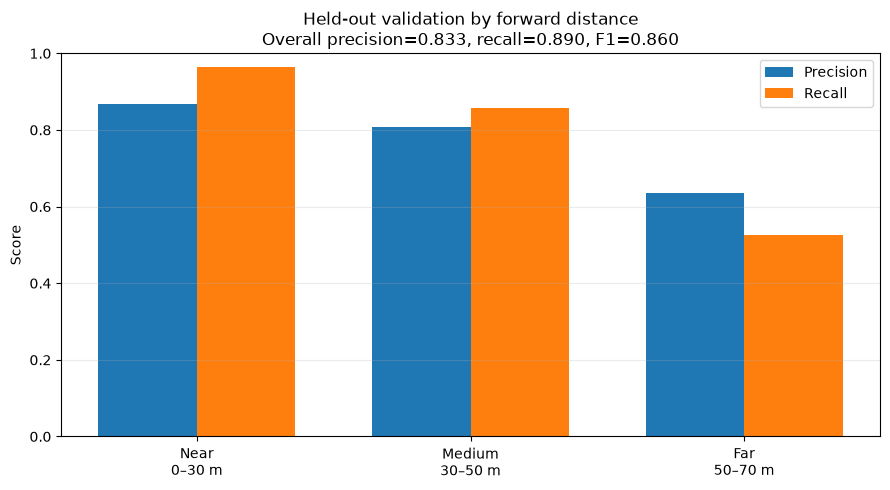

Saved validation artifacts to: /home/rahul/projects/kitti-lidar-detector/outputs/milestone_lidar_only
 - validation_frame_metrics.csv
 - validation_summary.json


In [6]:
if RUN_VALIDATION_EVALUATION:
    names = ["Near\n0–30 m", "Medium\n30–50 m", "Far\n50–70 m"]
    keys = ["near_0_30m", "medium_30_50m", "far_50_70m"]
    precisions = [
        validation_summary["per_distance"][key]["precision"]
        for key in keys
    ]
    recalls = [
        validation_summary["per_distance"][key]["recall"]
        for key in keys
    ]

    x = np.arange(len(names))
    width = 0.36
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(
        x - width / 2,
        precisions,
        width,
        label="Precision",
        color="tab:blue",
    )
    ax.bar(
        x + width / 2,
        recalls,
        width,
        label="Recall",
        color="tab:orange",
    )
    ax.set_xticks(x, names)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(
        "Held-out validation by forward distance\n"
        f"Overall precision={validation_summary['precision']:.3f}, "
        f"recall={validation_summary['recall']:.3f}, "
        f"F1={validation_summary['f1']:.3f}"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

    print("Saved validation artifacts to:", MILESTONE_DIR)
    print(" - validation_frame_metrics.csv")
    print(" - validation_summary.json")
